In [1]:
import pandas as pd

df = pd.read_csv("../data/07-1_study_habits.csv") # 상대경로

df.head()

,반,성별,공부시간,시험점수,용돈
0,C,여,2.7,63,11000
1,A,남,1.8,69,23000
2,C,남,3.5,74,27000
3,C,여,2.0,74,6000
4,A,여,3.2,64,25000


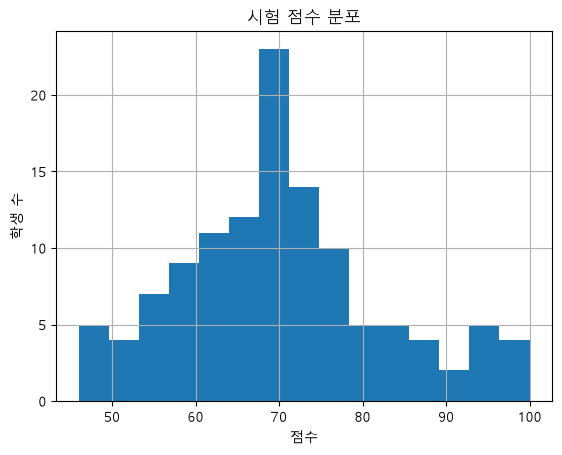

In [ ]:
import matplotlib.pyplot as plt
## 아래 코드는 한글 사용할 수 있도록 해줌
plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

df["시험점수"].hist(bins=15)    # bins: bar 구간 몇 개로 할건지
plt.title("시험 점수 분포")
plt.xlabel("점수")
plt.ylabel("학생 수")
plt.show()

#### 알 수 있는 부분
- 시험점서구ㅏ 정규분포 형채다

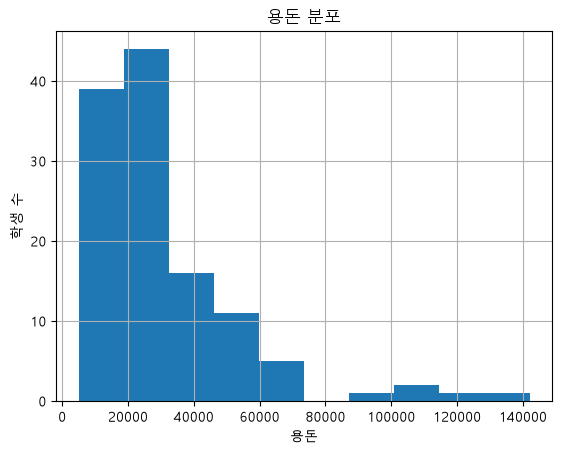

In [7]:
df["용돈"].hist(bins=10)
plt.title("용돈 분포")
plt.xlabel("용돈")
plt.ylabel("학생 수")
plt.show()

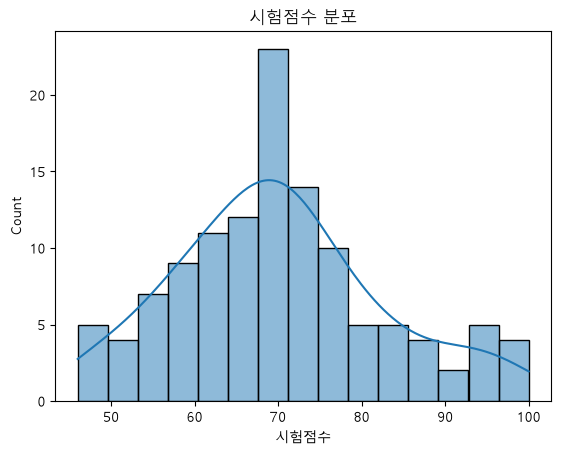

In [10]:
import seaborn as sns

sns.histplot(df["시험점수"],
             bins=15,
             kde=True) # kde: 가운데 선 넣기

plt.title("시험점수 분포")
plt.show()

### 박스 플롯 -> 이상치 보는 차트
- 사분위 수를 상자로, 이상치를 점으로 보이는 차트
- 가운데 %, Q1 ~ Q3
- 상자 밖의 선: 중앙값
- 수염 밖 점: 이상치 후보

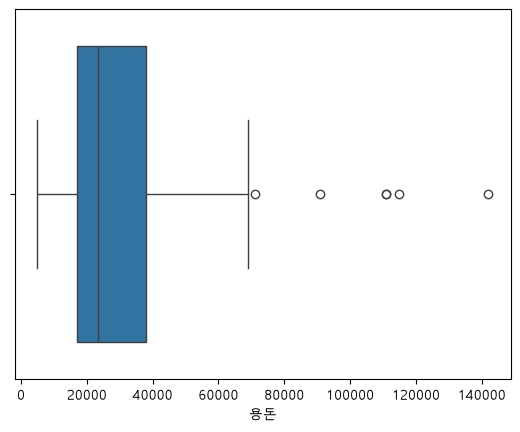

In [12]:
sns.boxplot(x=df["용돈"])
plt.show()

<Axes: >

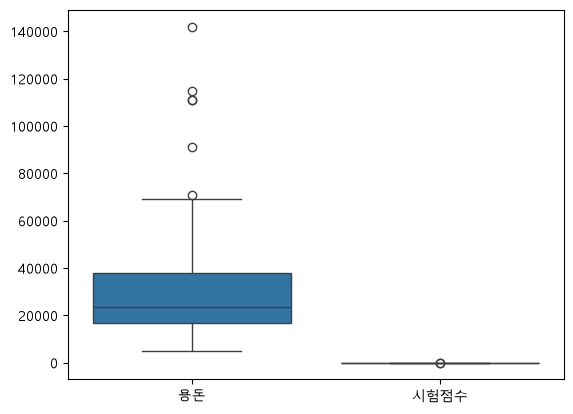

In [26]:
sns.boxplot(data=df[["용돈","시험점수"]])


In [20]:
# 이상치
Q1 = df["용돈"].quantile(0.25)
Q3 = df["용돈"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

21000.0


In [23]:
# 이상치 상한선
upper_bound = Q1 + 1.5*IQR
upper_bound

np.float64(48500.0)

In [24]:
lower_bound = Q1 - 1.5*IQR
lower_bound

np.float64(-14500.0)

In [25]:
# 이상치 상한선 이상 데이터 확인

df[df['용돈'] > upper_bound]

,반,성별,공부시간,시험점수,용돈
7,B,남,4.3,79,55000
14,B,남,4.0,69,111000
24,A,남,3.9,68,67000
36,C,여,4.6,73,50000
40,A,남,1.1,58,111000
41,C,남,4.9,64,49000
43,A,남,4.2,57,69000
46,B,여,1.1,64,62000
70,C,여,2.5,54,91000
71,B,남,3.5,73,71000


### 이상치 탐지
- 사기거래, 불량품, 이상 징후 발견

#### 무조건 삭제가 아니다
- 진짜 중요한 시간대나 이벤트 있을 수 있음
- 오히려 관리해야 할 데이터일 수 있음 -> 사유를 확인할 필요가 있음